In [ ]:
!pip install geemap earthengine-api rioxarray geopandas

In [ ]:
import ee
import geopandas as gpd
import geemap
from shapely.validation import make_valid
from shapely.ops import transform, unary_union
import os
import rioxarray as rxr
import pandas as pd 
import calendar
from datetime import datetime, timedelta

# ==========================================
# 0. PENGATURAN DIREKTORI DINAMIS
# ==========================================
# Melacak lokasi folder tempat script ini dijalankan
BASE_DIR = os.getcwd()

# Menentukan lokasi GeoJSON (Asumsi berada di folder yang sama dengan script)
file_geojson = os.path.join(BASE_DIR, "/kaggle/input/datasets/jerismeteo/kebumen-geojson/33.05_kecamatan.geojson")

# Menentukan folder utama untuk output GSMaP
FOLDER_BASE_OUTPUT = os.path.join(BASE_DIR, "data", "gsmap")

tahun = 2026

In [ ]:
from kaggle_secrets import UserSecretsClient

# 1. Buka brankas Kaggle dan ambil kunci rahasianya
brankas = UserSecretsClient()
ee_token = brankas.get_secret("EE_TOKEN")

# 2. Buat folder sembunyi di sistem komputer Kaggle
os.makedirs('/root/.config/earthengine', exist_ok=True)

# 3. Tulis ulang kunci tersebut menjadi file kredensial
with open('/root/.config/earthengine/credentials', 'w') as f:
    f.write(ee_token)

In [ ]:
# PSEUDOCODE (RINCI):
# 1) Inisialisasi Earth Engine.
# 2) Validasi file GeoJSON:
#    - Jika file tidak ada -> hentikan proses.
#    - Baca dengan geopandas.
#    - Pastikan CRS = EPSG:4326.
# 3) Bersihkan geometri agar aman dipakai di Earth Engine:
#    - Hapus geometri kosong/null.
#    - Paksa ke 2D.
#    - make_valid.
#    - Ambil hanya Polygon/MultiPolygon (termasuk dari GeometryCollection).
#    - buffer(0) untuk rapikan topologi.
#    - Validasi akhir, buang geometri yang masih invalid.
# 4) Konversi hasil geometri bersih menjadi ee.FeatureCollection.
# 5) Definisikan fungsi unduh tahunan:
#    - Input: tahun, batas_ee, output_base_dir.
#    - Buat folder output utama jika belum ada.
#    - Loop bulan 1..12.
#      - Hitung jumlah hari per bulan.
#      - Buat subfolder per bulan: YYYY_MM.
#      - Loop harian dari 1..jumlah_hari.
#        - Bentuk tanggal mulai dan tanggal akhir (H+1).
#        - Tentukan path .tif dan .nc.
#        - Jika .nc sudah ada -> skip.
#        - Ambil CHIRPS harian sesuai tanggal.
#        - Clip ke batas wilayah.
#        - Export ke GeoTIFF.
#        - Buka GeoTIFF dengan rioxarray.
#        - Pastikan band jadi 2D.
#        - Tambahkan dimensi time.
#        - Simpan ke NetCDF.
#        - Hapus file .tif sementara.
#        - Tampilkan status sukses/gagal.
# 6) Eksekusi fungsi untuk 1 tahun penuh.
# 7) Pastikan folder output CHIRPS (bukan gsmap).

# 1. Inisialisasi Earth Engine
ee.Initialize(project='sismonbanjir')

# 2. Persiapan Batas Wilayah
if not os.path.exists(file_geojson):
    raise FileNotFoundError(f"File GeoJSON tidak ditemukan di: {file_geojson}. Pastikan file ada di folder yang sama dengan script.")

gdf = gpd.read_file(file_geojson)

if gdf.crs != "EPSG:4326":
    gdf = gdf.to_crs("EPSG:4326")

# ==========================================
# --- KUNCI PERBAIKAN (CLEANING TOPOLOGI) ---
# ==========================================
print("Membersihkan geometri GeoJSON yang cacat...")
gdf = gdf[gdf.geometry.notna()].copy()

def _to_2d(geom):
    if geom is None or geom.is_empty: 
        return None
    return transform(lambda x, y, z=None: (x, y), geom)

def _extract_polygonal(geom):
    if geom is None or geom.is_empty: 
        return None
    if geom.geom_type in ("Polygon", "MultiPolygon"): 
        return geom
    if geom.geom_type == "GeometryCollection":
        polys = [g for g in geom.geoms if g.geom_type in ("Polygon", "MultiPolygon")]
        if not polys: 
            return None
        return unary_union(polys)
    return None

def _clean_geom(geom):
    if geom is None or geom.is_empty: 
        return None
    geom = _to_2d(geom)
    geom = make_valid(geom)
    geom = _extract_polygonal(geom)
    if geom is None or geom.is_empty: 
        return None
    geom = geom.buffer(0)
    if geom is None or geom.is_empty: 
        return None
    if not geom.is_valid:
        geom = make_valid(geom)
        geom = _extract_polygonal(geom)
    if geom is None or geom.is_empty or not geom.is_valid: 
        return None
    return geom

gdf["geometry"] = gdf["geometry"].apply(_clean_geom)
gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()
gdf = gdf[gdf.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
gdf.reset_index(drop=True, inplace=True)

if gdf.empty:
    raise ValueError("Semua geometri tidak valid setelah proses cleaning.")

print("Mengonversi ke Earth Engine...")
geojson_fc = gdf.__geo_interface__
batas_kebumen = ee.FeatureCollection(geojson_fc["features"])

# ==========================================
# 3. FUNGSI PERULANGAN UNDUH TAHUNAN
# ==========================================
def unduh_chirps_satu_tahun(tahun, batas_ee, output_base_dir):
    os.makedirs(output_base_dir, exist_ok=True)

    print(f"\n=== Memulai Unduhan CHIRPS Tahun {tahun} ===")
    print(f"Output utama: {output_base_dir}")

    for bulan in range(1, 13):
        _, jml_hari = calendar.monthrange(tahun, bulan)
        output_dir_bulan = os.path.join(output_base_dir, f"{tahun}_{bulan:02d}")
        os.makedirs(output_dir_bulan, exist_ok=True)

        print(f"\n--- Bulan {bulan:02d}-{tahun} ({jml_hari} hari) ---")
        print(f"Folder output: {output_dir_bulan}")

        for hari in range(1, jml_hari + 1):
            tgl_mulai_obj = datetime(tahun, bulan, hari)
            tgl_mulai = tgl_mulai_obj.strftime("%Y-%m-%d")
            tgl_akhir = (tgl_mulai_obj + timedelta(days=1)).strftime("%Y-%m-%d")

            tif_path = os.path.join(output_dir_bulan, f"chirps_{hari:02d}_{bulan:02d}_{tahun}.tif")
            nc_path = os.path.join(output_dir_bulan, f"chirps_{hari:02d}_{bulan:02d}_{tahun}.nc")

            if os.path.exists(nc_path):
                print(f"[{tgl_mulai}] Sudah ada, dilewati...")
                continue

            print(f"[{tgl_mulai}] Mengunduh...", end=" ")

            try:
                dataset = (
                    ee.ImageCollection("UCSB-CHC/CHIRPS/V3/DAILY_SAT")
                    .filter(ee.Filter.date(tgl_mulai, tgl_akhir))
                )

                precipitation = dataset.select("precipitation").first().clip(batas_ee)

                geemap.ee_export_image(
                    precipitation,
                    filename=tif_path,
                    region=batas_ee.geometry(),
                    scale=5566,
                    file_per_band=False
                )

                with rxr.open_rasterio(tif_path, masked=True) as da_asli:
                    da = da_asli.squeeze("band", drop=True) if "band" in da_asli.dims else da_asli
                    da.name = "precipitation"
                    da = da.expand_dims(time=[pd.to_datetime(tgl_mulai)])
                    da.to_netcdf(nc_path)

                os.remove(tif_path)
                print("✓")

            except Exception as e:
                print(f"❌ (Error: {e})")

# ==========================================
# 4. EKSEKUSI FUNGSI (TAHUNAN)
# ==========================================
FOLDER_BASE_OUTPUT = os.path.join(BASE_DIR, "data", "chirps")
unduh_chirps_satu_tahun(
    tahun=tahun,
    batas_ee=batas_kebumen,
    output_base_dir=FOLDER_BASE_OUTPUT
)

Membersihkan geometri GeoJSON yang cacat...
Mengonversi ke Earth Engine...

--- Memulai Unduhan Bulan 01-2026 ---
Output: d:\Github\Catatan_Meteorologi\Projek_Downscale\data\chirps\2026_01
[2026-01-01] Mengunduh... Generating URL ...
Please wait ...
Data downloaded to d:\Github\Catatan_Meteorologi\Projek_Downscale\data\chirps\2026_01\chirps_01_01_2026.tif
✓
[2026-01-02] Mengunduh... Generating URL ...
Please wait ...
Data downloaded to d:\Github\Catatan_Meteorologi\Projek_Downscale\data\chirps\2026_01\chirps_02_01_2026.tif
✓
[2026-01-03] Mengunduh... Generating URL ...
Please wait ...
Data downloaded to d:\Github\Catatan_Meteorologi\Projek_Downscale\data\chirps\2026_01\chirps_03_01_2026.tif
✓
[2026-01-04] Mengunduh... Generating URL ...
Please wait ...
Data downloaded to d:\Github\Catatan_Meteorologi\Projek_Downscale\data\chirps\2026_01\chirps_04_01_2026.tif
✓
[2026-01-05] Mengunduh... Generating URL ...
Please wait ...
Data downloaded to d:\Github\Catatan_Meteorologi\Projek_Downscale\

Membuka file: D:\Github\Catatan_Meteorologi\Projek_Downscale\data\chirps\2026_1\chirps_01_01_2026.nc


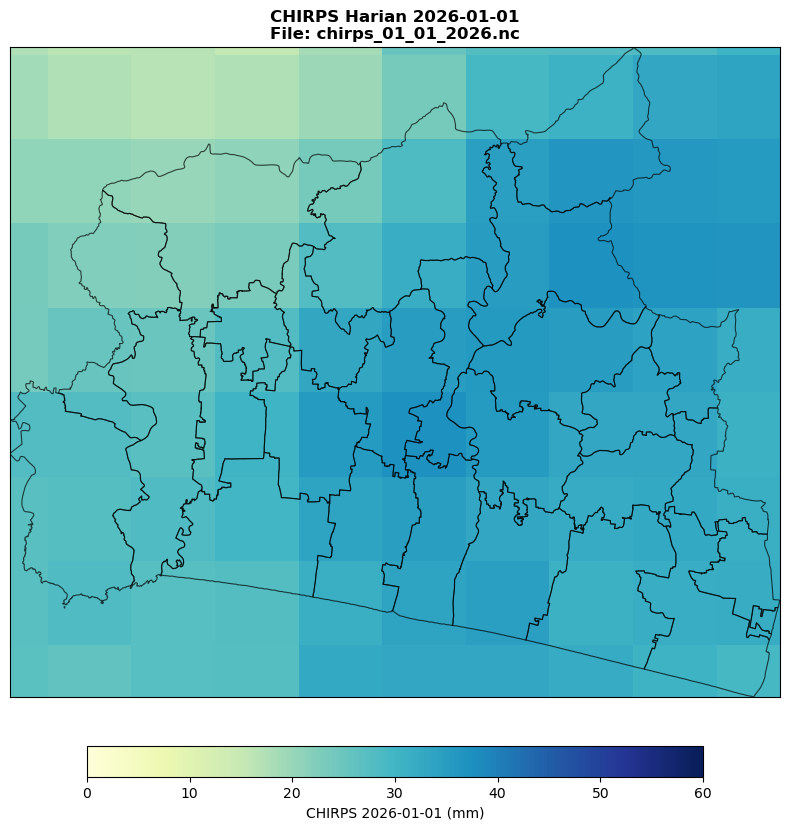

In [ ]:
# PSEUDOCODE:
# 1) Tentukan file NetCDF bulanan Januari yang spesifik.
# 2) Buka sebagai DataArray (atau ambil variabel utama dari Dataset).
# 3) Cek apakah dimensi "time" ada:
#    - Jika ada: pilih tanggal "2025-01-01" dengan .sel(time=...).
#    - Jika tidak ada: hentikan proses karena file bulanan hasil agregasi tidak menyimpan data harian.
# 4) Simpan hasil tanggal tunggal ke file baru agar deterministik.
# 5) Plot hasil tanggal tunggal.

# ===== [CELL 2] Ambil 1 tanggal spesifik dari NetCDF Januari =====
import os
import xarray as xr
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt

BASE_DIR = os.getcwd() 

# Parameter
target_date = "2026-01-01"
file_geojson = os.path.join(BASE_DIR, "33.05_kecamatan.geojson")
netcdf_file = os.path.join(BASE_DIR, "data", "chirps", "2026_1", "chirps_01_01_2026.nc")

if not os.path.isfile(netcdf_file):
    raise FileNotFoundError(f"File tidak ditemukan: {netcdf_file}")

print(f"Membuka file: {netcdf_file}")

# Buka data
try:
    da = xr.open_dataarray(netcdf_file)
except Exception:
    ds = xr.open_dataset(netcdf_file)
    da = ds["precipitation"] if "precipitation" in ds.data_vars else ds[list(ds.data_vars)[0]]

# Ambil tanggal spesifik
if "time" not in da.dims:
    raise ValueError(
        "File NetCDF ini tidak punya dimensi time (kemungkinan sudah agregasi bulanan). "
        "Tidak bisa mengambil tanggal 2025-01-01 dari file ini."
    )

da_day = da.sel(time=target_date)

# Rapikan dimensi
if "band" in da_day.dims:
    da_day = da_day.squeeze("band", drop=True)
if "time" in da_day.dims and da_day.sizes.get("time", 1) == 1:
    da_day = da_day.squeeze("time", drop=True)

try:
    if da_day.rio.crs is None:
        da_day = da_day.rio.write_crs("EPSG:4326", inplace=False)
except Exception:
    pass

# Plot
gdf = gpd.read_file(file_geojson)
if gdf.crs != "EPSG:4326":
    gdf = gdf.to_crs("EPSG:4326")
minx, miny, maxx, maxy = gdf.total_bounds

da_plot = da_day
try:
    if "x" in da_day.dims and "y" in da_day.dims:
        da_plot = da_day.rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)
except Exception:
    pass

fig, ax = plt.subplots(figsize=(8, 10))
da_plot.plot(
    ax=ax,
    cmap="YlGnBu",
    vmin=0,
    vmax=60,  # sesuaikan skala harian
    cbar_kwargs={"label": f"CHIRPS {target_date} (mm)", "orientation": "horizontal", "pad": 0.05, "shrink": 0.8}
)
gdf.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.8, alpha=0.7)
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
plt.title(f"CHIRPS Harian {target_date}\nFile: {os.path.basename(netcdf_file)}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()